# Follower loading

Cantilever beam subjected to follower end load.

In [ ]:
import veux
import numpy as np
from veux.motion import Motion
import xara
import matplotlib.pyplot as plt

## Modeling

In [3]:
def create_cantilever(ne, element, transform="Corotational02"):
    model = xara.Model(ndm=3, ndf=6)

    L  = 100

    nen = 2
    nmn = ne*(nen-1)+1

    sec = 1
    A = 1.61538e8
    I = 3.5e7
    model.section("ElasticFrame", sec,
                    E=1,
                    G=1,
                    A=A,
                    Ay=A,
                    Az=A,
                    Iy=I*100,
                    Iz=I,
                    J =I
    )

    model.geomTransf(transform, 1, (0,0,1))

    for i,x in enumerate(np.linspace(0, L, nmn)):
        model.node(i, (x,0,0))

    for i in range(ne):
        start = i * (nen - 1)
        nodes = list(range(start, start + nen))
        model.element(element, i+1, nodes,
                      section=sec, transform=1, shear=1)

    model.fix(0,  (1,1,1,  1,1,1))

    return model

## Analysis

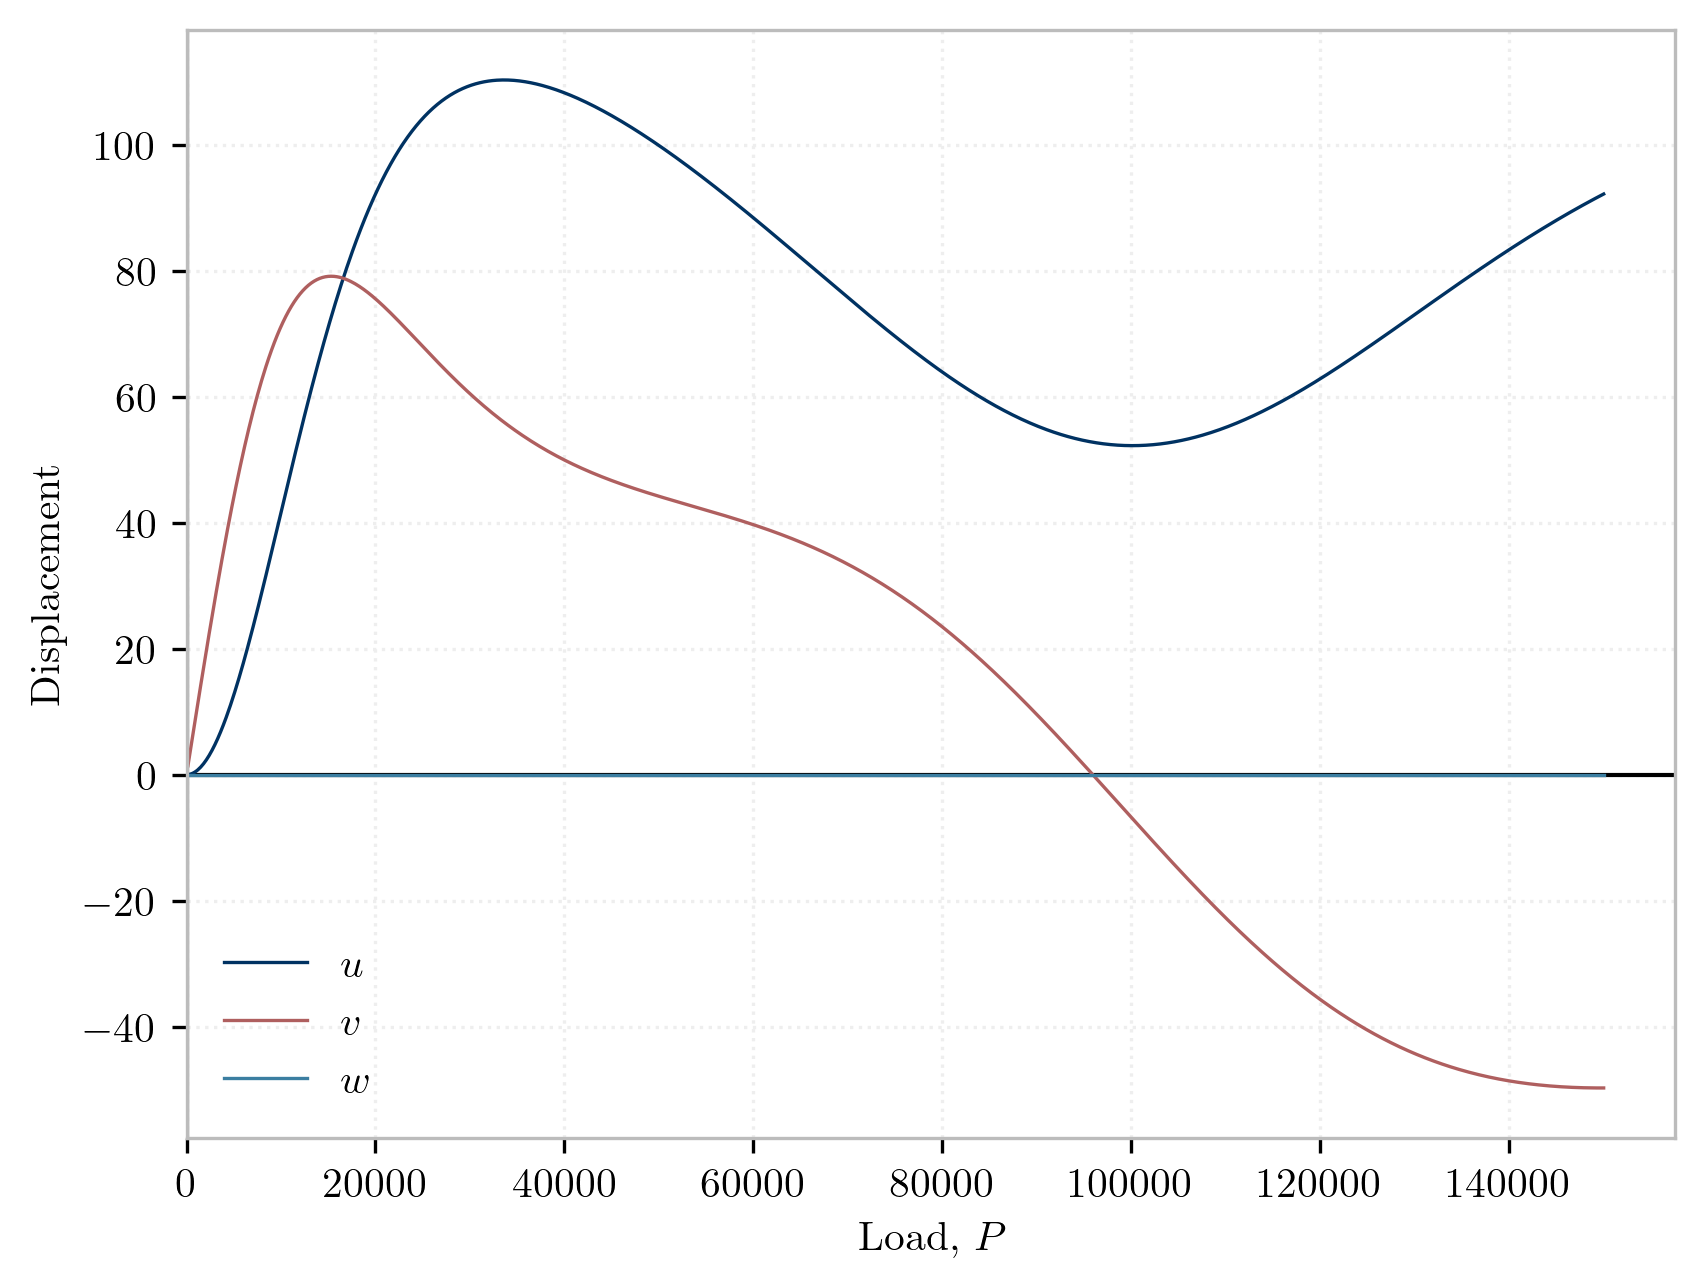

In [4]:
def analyze(element):
    ne = 10

    model = create_cantilever(ne, element=element)
    artist = veux.create_artist(model, model_config=dict(extrude_outline="square"))
    artist.draw_nodes(size=10)
    artist.draw_sections()
    motion = Motion(artist)

    #
    # Apply vertical load
    #
    speed  = 1/3000 # animation frames
    Pmax   = 150e3 # N


    pattern = xara.StaticPattern([
        xara.FrameLoad(model,
                    shape="Point",
                    force = [0, 1, 0],
                    basis = "director",
                    offset=[1.0,0,0],
                    elements=[ne]
        )
    ])

    # Add the pattern to the model
    model.pattern(pattern)

    model.system('Umfpack')
    model.integrator("LoadControl", Pmax/1000)
    # model.test("NormDispIncr", 1e-10, 500, 1)
    model.test("Energy", 1e-18, 10, 0)
    # model.test("Residual", 1e-6, 200, 2)
    model.algorithm("NewtonLineSearch", 0.8)
    model.analysis("Static")

    u = []
    v = []
    w = []
    P = []
    while model.getTime() < Pmax:
        if model.analyze(1) != 0:
            print(f"Failed at time = {100*model.getTime()/Pmax}% with v = {v[-1]}")
            break
        motion.advance(time=model.getTime()*speed)
        motion.draw_sections(rotation=model.nodeRotation,
                             position=model.nodeDisp)
        u.append(-model.nodeDisp(ne, 1))
        v.append( model.nodeDisp(ne, 2))
        w.append( model.nodeDisp(ne, 3))
        P.append( model.getTime())


    if True:
        fig, ax = plt.subplots()
        ax.set_xlabel("Load, $P$")
        ax.set_ylabel(r"Displacement")
        ax.axvline(0, color='black', linestyle='-', linewidth=1)
        ax.axhline(0, color='black', linestyle='-', linewidth=1)
        ax.plot(P, u, label="$u$")
        ax.plot(P, v, label="$v$")
        ax.plot(P, w, label="$w$")
        ax.set_xlim([0, None])
        ax.legend()
        plt.show()

    motion.add_to(artist.canvas)
    return artist


analyze(element = "ForceFrame")

